# 05 · What to control for — and what NOT to (pathmc)

**The business decision behind the statistics.** Every effect estimate in every other notebook depends on
a choice made *before* any model runs: **which variables to control for** (put in the model / adjust for).
Get it wrong and the number is biased no matter how fancy the estimator. The instinct "throw in every
column we have" is actively dangerous. This is the notebook that lets you tell a skeptical CMO *exactly why*
you controlled for what you did.

### The four roles a variable can play — and the rule for each

To "**control for**" (equivalently *adjust for*, *condition on*) a variable $W$ means to hold it fixed when
comparing treated vs untreated — e.g. by including it in the regression. Whether that helps or hurts depends
entirely on $W$'s causal role between treatment $T$ and outcome $Y$:

- **Confounder** — a common cause of *both* $T$ and $Y$ (e.g. customer loyalty drives both who gets emailed
  and how much they spend). It opens a spurious "backdoor" path $T \leftarrow W \rightarrow Y$. → **Control
  for it.** Failing to is the classic omitted-variable bias.
- **Mediator** — a variable *on the causal path* $T \rightarrow W \rightarrow Y$ (the effect flows through
  it). → **Do NOT control for it** — you'd subtract out part of the very effect you're trying to measure.
- **Collider** — a common *effect* of $T$ and $Y$ ($T \rightarrow W \leftarrow Y$). Conditioning on a
  collider *opens* a path that was closed, **manufacturing** a correlation that isn't causal. → **Do NOT.**
- **M-bias collider** — a *pre-treatment* variable that is a collider between two hidden causes. → **Do NOT**
  — proof that "just control for everything measured before treatment" is wrong.

The tool that decides this formally is the **backdoor criterion** on the **DAG** (the causal graph): a valid
**adjustment set** is any set of variables that blocks every backdoor path from $T$ to $Y$ *without*
including a mediator or a descendant of $T$. `pathmc` reads the graph and enumerates the valid sets for us.

### What this notebook does

(a) a **gallery** of the four structures with the correct action; (b) `pathmc` enumerates the admissible
adjustment set and flags colliders straight from the DAG; (c) we show the bias of each wrong choice **in
euros**; (d) we bound the residual risk from an *unobserved* confounder with a sensitivity contour and an
**E-value** (the minimum confounder strength that could explain the effect away).

7-step contract, with **identification** (which variables make the effect recoverable) — not estimation —
as the whole point.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, estimators as est, metrics, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 17

## 1b · The four structures — a control-or-not gallery

Every "should I control for W?" question reduces to *what role W plays* between treatment T and
outcome Y:


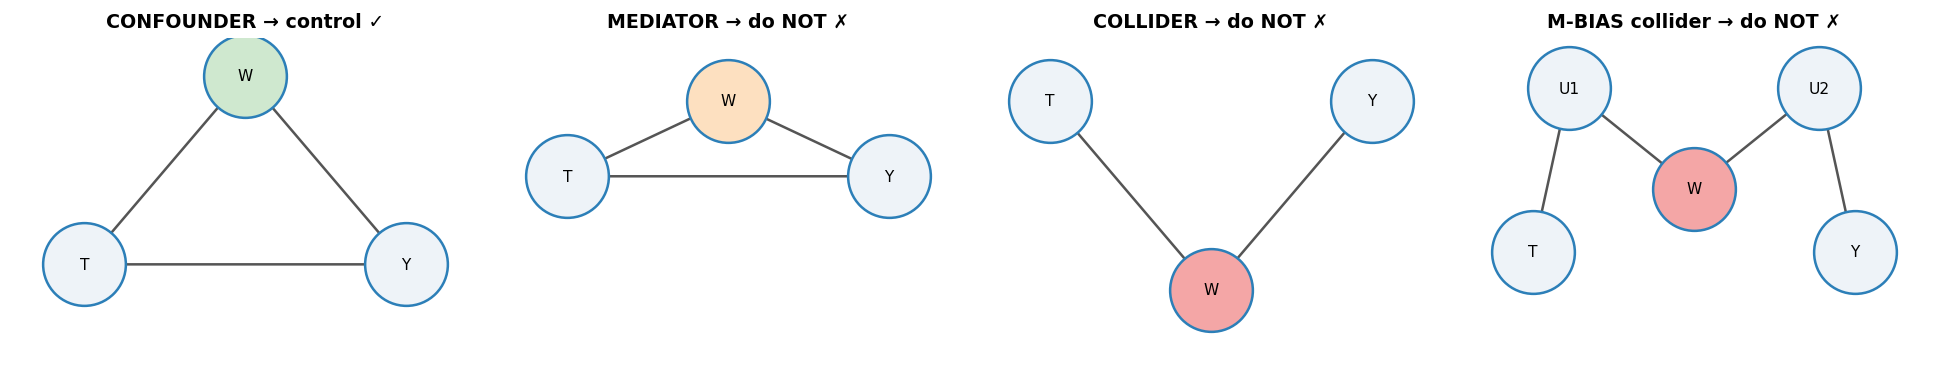

In [2]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.0))
plots.draw_dag(ax[0], {"W":(0.5,1.0),"T":(0.05,0.25),"Y":(0.95,0.25)},
    [("W","T"),("W","Y"),("T","Y")], node_colors={"W":"#cfe8cf"}, title="CONFOUNDER → control ✓")
plots.draw_dag(ax[1], {"T":(0.05,0.6),"W":(0.5,0.9),"Y":(0.95,0.6)},
    [("T","W"),("W","Y"),("T","Y")], node_colors={"W":"#fde0c0"}, title="MEDIATOR → do NOT ✗")
plots.draw_dag(ax[2], {"T":(0.05,0.9),"Y":(0.95,0.9),"W":(0.5,0.15)},
    [("T","W"),("Y","W")], node_colors={"W":"#f4a6a6"}, title="COLLIDER → do NOT ✗")
plots.draw_dag(ax[3], {"U1":(0.15,0.95),"U2":(0.85,0.95),"T":(0.05,0.3),"Y":(0.95,0.3),"W":(0.5,0.55)},
    [("U1","T"),("U1","W"),("U2","W"),("U2","Y")], node_colors={"W":"#f4a6a6"}, title="M-BIAS collider → do NOT ✗")
fig.tight_layout()

- **Confounder** (common cause of T and Y): **control** — it opens a backdoor path.
- **Mediator** (on the causal path T→W→Y): **do not** — you'd remove part of the effect you want.
- **Collider** (common effect of T and Y): **do not** — conditioning *opens* a spurious path.
- **M-bias collider** (pre-treatment, common effect of two latents that separately cause T and Y):
  **do not** — even a *pre-treatment* variable can be a trap. "Adjust for everything pre-treatment"
  is wrong.


## 2 · Simulate a ground truth

`email → spend` with a **true effect of €6**. Around it: **`loyalty`** is a **confounder**
(drives both email and spend → must control); **`responded`** is a **collider** (caused by both
email and spend → tempting but poisonous); **`opened_email`** is a post-treatment descendant.


In [3]:
df, true_ate = dgp.dag_control_demo(n=2000, seed=SEED)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")
df.head()

TRUE effect of email on spend = €6.0


,email,loyalty,opened_email,responded,spend
0,1.0,1.101262,1.0,0.0,27.705363
1,0.0,0.338431,0.0,0.0,17.425501
2,0.0,-0.539972,0.0,0.0,9.602566
3,0.0,-1.260242,0.0,0.0,5.056443
4,1.0,-1.894621,0.0,0.0,7.175152


## 3 · Identify — let the DAG choose the adjustment set

The **backdoor criterion**: an admissible set $Z$ blocks every backdoor path T→Y and contains no
descendant of T. `pathmc` enumerates admissible sets and flags colliders straight from the graph
— **no data needed**, because identification is about structure, not numbers.


In [4]:
spec = '''
email        ~ b1*loyalty
opened_email ~ b2*email
responded    ~ b3*email + b4*spend
spend        ~ b5*email + b6*loyalty
'''
m = pathmc.model(spec, data=df)
print("Admissible adjustment set(s) for email → spend:", m.adjustment_sets("email", "spend"))
print("Identifiable:", m.is_identifiable("email", "spend"))
print()
for cand in [{"loyalty"}, {"loyalty","responded"}, {"loyalty","opened_email"}, set()]:
    warns = m.collider_warnings(cand, "email", "spend")
    print(f"control for {cand or '{}'}:  " + ("; ".join(warns) if warns else "OK — no collider opened"))

Admissible adjustment set(s) for email → spend: [{'loyalty'}]
Identifiable: True

control for {'loyalty'}:  OK — no collider opened
control for {'responded', 'loyalty'}:  'responded' is a collider between 'email' and 'spend'. Conditioning on it may open a spurious path and introduce bias.
control for {'loyalty', 'opened_email'}:  OK — no collider opened
control for {}:  OK — no collider opened


(Read the printout above as the machine doing the reasoning: it names `{loyalty}` as the one adjustment
set that closes the backdoor, confirms the effect is identifiable, and — critically — *warns* when a
candidate set includes `responded`, because that variable is a collider. This is the DAG logic from the
intro, applied automatically.)

## 4–5 · Estimate & Validate — every control choice, in €

Now we make the abstract warnings concrete and expensive. We estimate the same email→spend effect **five
ways**, each time controlling for a different set of variables, and compare to the known true €6:

- **nothing** (naive) — leaves the loyalty confounding in, so it's biased *up*;
- **{loyalty}** — the DAG-endorsed set; should land on €6;
- **{loyalty, responded}** — adds a *collider*, which opens a spurious path;
- **{loyalty, opened}** — adds a *post-treatment descendant*, another no-no;
- **everything** — the "throw it all in" instinct, which stacks the errors.

The punchline is that **the sign and rough size of each bias is predictable from the graph *before* you run
anything**: omitting a confounder biases up; conditioning on a collider or a post-treatment variable biases
in the direction of the association it induces. Controlling for more is *not* safer.


naive (nothing)            € 9.45   (error +3.45)
{loyalty} ✓                € 6.09   (error +0.09)
{loyalty,responded} ✗      € 5.58   (error -0.42)
{loyalty,opened} ✗         € 5.45   (error -0.55)
everything ✗               € 4.97   (error -1.03)


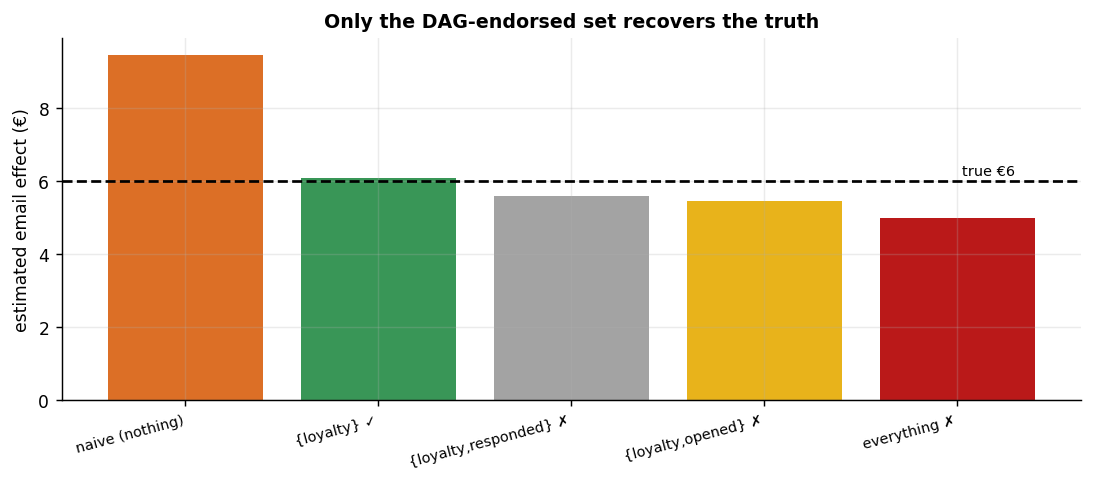

In [5]:
def ols_effect(controls):
    X = np.column_stack([np.ones(len(df)), df["email"].values] + [df[c].values for c in controls])
    return np.linalg.lstsq(X, df["spend"].values, rcond=None)[0][1]

choices = {
    "naive (nothing)": [], "{loyalty} ✓": ["loyalty"],
    "{loyalty,responded} ✗": ["loyalty","responded"],
    "{loyalty,opened} ✗": ["loyalty","opened_email"],
    "everything ✗": ["loyalty","responded","opened_email"],
}
ests = {k: ols_effect(v) for k, v in choices.items()}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(ests)), list(ests.values()), color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(ests))); ax.set_xticklabels(list(ests.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("estimated email effect (€)"); ax.set_title("Only the DAG-endorsed set recovers the truth")
fig.tight_layout()
for k, v in ests.items(): print(f"{k:26s} €{v:5.2f}   (error {v-true_ate:+.2f})")

**How to read this.** Only the green bar — `{loyalty}`, the set the DAG endorsed — lands on the true €6.
The naive bar overshoots (confounding left in); adding the collider `responded` or the post-treatment
`opened` *pulls the estimate away* even though we already had the right confounder; and "everything" is the
worst of all. The moral for a practitioner is blunt: **the model can't tell you it's biased — the bars all
look like plausible numbers.** The only defence is choosing the control set from the causal graph *before*
looking at the estimates, which is precisely what makes the answer defensible to a skeptic.

## 6 · Decide, in euros — the stakes of the control choice, with a robustness statement

Two parts. **(a) The euro stakes.** Getting the control set wrong isn't academic: budgeting a campaign on the
naive (confounded) estimate books *phantom* incremental revenue, which we price out below across a realistic
campaign — the concrete cost of skipping the DAG. **(b) The robustness statement.** Identification is
untestable, so we bound the residual risk: how strong would an *unobserved* confounder have to be to overturn
the conclusion? `pathmc.sensitivity` gives the tipping surface (with the grid widened so the zero-crossing is
actually reachable), and the **E-value** summarises it as a single **risk-ratio-scale** number — which is why
the euro effect must *not* be plotted on the same axis.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_spend, beta_spend, sigma_email, beta_email, beta_responded, beta_opened_email, sigma_responded, sigma_opened_email]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Observed adjusted ATE €6.07 (true €6.0)  ·  E-value ≈ 3.29
An unmeasured confounder would need ~3.3× association (risk-ratio scale) with BOTH email and
spend to explain the effect away — ask the domain expert whether anything that strong is plausible.

Euro stakes: budgeting on the naive €9.45 instead of the DAG-endorsed €6.09 overstates incremental
revenue by €168,031 across a 50,000-customer campaign — phantom lift that would justify overspending on the email.


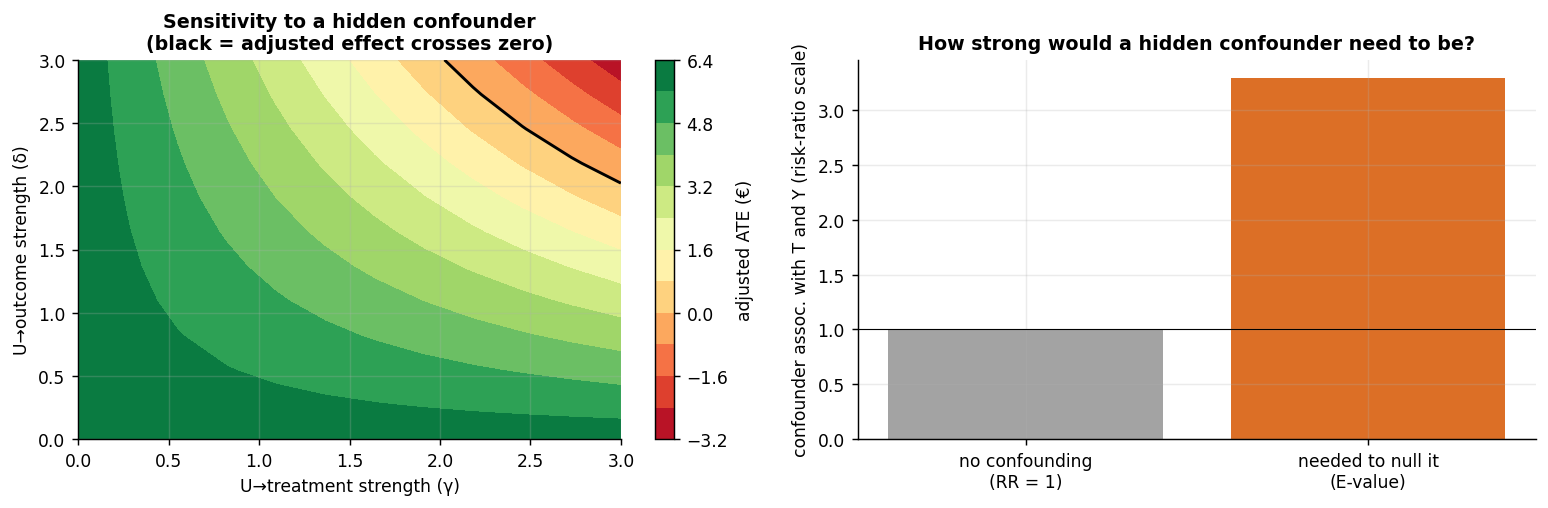

In [6]:
m.fit(random_seed=SEED, progressbar=False, **FIT)
# pathmc's bias model is adjusted_ATE = observed_ATE - gamma*delta, so the grid must reach
# gamma*delta ~ the observed effect for a "crosses zero" line to exist. The default (0,1)^2 caps
# the bias at 1 (< the €6 effect) and can NEVER cross zero — we widen the ranges to (0,3)^2.
sens = m.sensitivity("spend", "email", n_grid=12, gamma_range=(0.0, 3.0), delta_range=(0.0, 3.0))
adj = np.asarray(sens.adjusted_ate_mean); COSTLINE = 0.0
evalue = metrics.e_value(float(sens.observed_ate), cost=COSTLINE, sd=float(df["spend"].std()))
print(f"Observed adjusted ATE €{float(sens.observed_ate):.2f} (true €{true_ate:.1f})  ·  E-value ≈ {evalue:.2f}")

g, d = np.meshgrid(sens.gamma_values, sens.delta_values, indexing="ij")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cs = ax[0].contourf(g, d, adj, levels=12, cmap="RdYlGn"); ax[0].contour(g, d, adj, levels=[0], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[0], label="adjusted ATE (€)")
ax[0].set_xlabel("U→treatment strength (γ)"); ax[0].set_ylabel("U→outcome strength (δ)")
ax[0].set_title("Sensitivity to a hidden confounder\n(black = adjusted effect crosses zero)")
# E-value on the RISK-RATIO scale only — the euro effect does NOT belong on this axis.
ax[1].bar(["no confounding\n(RR = 1)", "needed to null it\n(E-value)"], [1.0, evalue],
          color=[plots.GREY, plots.ORANGE], alpha=0.9); ax[1].axhline(1.0, color="k", lw=0.6)
ax[1].set_ylabel("confounder assoc. with T and Y (risk-ratio scale)")
ax[1].set_title("How strong would a hidden confounder need to be?")
fig.tight_layout()
print(f"An unmeasured confounder would need ~{evalue:.1f}× association (risk-ratio scale) with BOTH email and\n"
      f"spend to explain the effect away — ask the domain expert whether anything that strong is plausible.")

# The euro stakes of the control choice: budgeting on the naive (confounded) estimate books phantom lift.
CAMPAIGN_N = 50_000
naive_ate, correct_ate = ests["naive (nothing)"], ests["{loyalty} ✓"]
overstatement = (naive_ate - correct_ate) * CAMPAIGN_N
print(f"\nEuro stakes: budgeting on the naive €{naive_ate:.2f} instead of the DAG-endorsed €{correct_ate:.2f} "
      f"overstates incremental\nrevenue by €{overstatement:,.0f} across a {CAMPAIGN_N:,}-customer campaign — "
      f"phantom lift that would justify overspending on the email.")

## 6b · The stakes on **real** data (LaLonde) — good vs bad adjustment

This isn't an academic worry. On the famous **LaLonde** job-training data (fetched from a public URL —
you provide nothing), the *right* control set recovers the known experimental effect (~\$1,800) while a
careless one does not. It is the canonical demonstration that *what you adjust for* can flip the sign of
your conclusion. Gated on `CMP_REAL=1`.


In [7]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    ll = data.load_lalonde()
    T2, Y2 = ll["treat"].values, ll["re78"].values
    good = ["age","educ","black","hispan","married","nodegree","re74","re75"]   # pre-treatment confounders
    naive2 = Y2[T2==1].mean() - Y2[T2==0].mean()
    Dg = np.column_stack([np.ones(len(ll)), T2, ll[good].values])
    adj2 = np.linalg.lstsq(Dg, Y2, rcond=None)[0][1]
    print(f"Effect of training on 1978 earnings (observational comparison group):")
    print(f"  no controls (naive)                : ${naive2:,.0f}   (badly biased — groups differ hugely)")
    print(f"  adjust for the 8 pre-treatment cov.: ${adj2:,.0f}   (recovers the ~$1,800 experimental truth)")
    print("Same data, opposite conclusions — which is exactly why the control-set choice is the ballgame.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.")

Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.


## 7 · Caveats

- **The graph is an assumption.** `pathmc` gives the correct set *for the DAG you drew*. A missing
  or reversed edge changes the advice — the DAG must encode defensible domain knowledge.
- **Colliders hide in "obvious" controls.** "engaged", "responded", "opened", "clicked" are almost
  always post-treatment; excluding them feels wrong to practitioners and is exactly right.
- **Front-door as a fallback.** If a T–Y confounder is genuinely unmeasured but a fully-mediating
  measured variable exists, the front-door adjustment can still identify the effect — a tool to
  keep in reserve.
- **Sensitivity ≠ proof.** A high E-value means "robust to plausible hidden confounding," not
  "unconfounded." Pair it with the expert's judgement about what could be missing.
